# Finding patterns with quantum computers

In [1]:
import numpy as np
from fractions import Fraction
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
backend = AerSimulator()

[Generating random numbers](01_A%20simple%20and%20useful%20quantum%20algorithm.ipynb), [computing non-uniform probability distributions](02_Other%20random%20distributions%20on%20quantum%20computers.ipynb), and [running multiple digital operations simultaneously](03_Digital%20operations%20on%20quantum%20computers.ipynb) are all useful demonstrations of what quantum computers can do. [Grover's algorithm](04_Solving%20a%20problem%20with%20quantum%20computers.ipynb) took this further: it showed how to find a specific answer quadratically faster than a classical computer by amplifying the row corresponding to the right answer.

Another class of problem is where the goal is not to find a specific answer, but to find a *hidden pattern*. You do not know specifically what you are looking for, but you know the answer repeats with some period. This notebook introduces an algorithm for the **Quantum Fourier Transform (QFT)** — the quantum computing technique that finds hidden periods in a state vector. It is also the key ingredient in [Shor's algorithm](https://en.wikipedia.org/wiki/Shor%27s_algorithm), which can factor large numbers exponentially faster than any known digital approach. Factoring large numbers underlies most modern [public-key cryptography](https://en.wikipedia.org/wiki/Public-key_cryptography), which is why quantum computing is taken seriously as a long-term cryptographic concern.

Before getting to what makes the *quantum* Fourier transform different, it is worth understanding what the Fourier transform already does on a digital computer.

### The (classical) Fourier transform

Finding a hidden period in a list of numbers is not a new problem. Digital computers solve it using the [**Fourier transform**](https://en.wikipedia.org/wiki/Fourier_transform), which takes a list of values and answers the question: *what repeating patterns are hidden in these numbers, and how strongly does each one appear?*

A concrete example: suppose you record a sound. That recording is a list of thousands of numbers — the air pressure at each sequential moment in time. The Fourier transform converts this list into a different list, where each entry represents a frequency (like a musical note), and the value for that entry tells you how much of that frequency is present. A pure tone, like a note made by a tuning fork, produces one large entry for that note, and mostly zeros everywhere else. A musical chord produces multiple large entries. This is exactly what audio software does when it draws a frequency spectrum.

The same idea applies to any periodic data, not just sound. If you had a sequence of data that repeated every 7 steps, the Fourier transform of that function would produce a spike at the entry corresponding to "repeats every 7."

A digital computer can perform this calculation efficiently enough to run in real time on a phone. For most practical pattern-finding tasks, the digital Fourier transform is the right tool.

**The QFT is different in two ways:**

First, it operates on a *quantum* state vector. As mentioned back in [the second article](02_Other%20random%20distributions%20on%20quantum%20computers.ipynb), the values in each state vector row are probability amplitudes, not ordinary probabilities. As well as being able to take negative values, the amplitudes can have a direction, as we'll soon see. The QFT uses the directional amplitude to concentrate amplitudes toward the rows that correspond to real frequencies while the rest of the directions cancel out.

Second, the QFT is dramatically faster than any known digital Fourier transform approach for large data sets. The speedup is not merely incremental. For the sizes of data relevant to cryptography, no digital computer could finish in any practical amount of time, while the quantum version completes quickly. This exponential speedup is what makes Shor's algorithm possible.

The catch: you cannot simply read out the final state vector, as we've seen. Measuring the state vector simply returns a single row of it. This means the QFT is only useful when the input data set has a strong enough repeating pattern that the few rows representing the repetition show up reliably when measured over multiple runs. A periodic input is exactly the case where that happens — and preparing such a periodic quantum state is the hard part of Shor's algorithm.

To make directional amplitudes work, we need to extend the way we've been using amplitudes.

### Extending the amplitude model

So far in these notebooks, the numbers in the quantum state vector (also known as probability amplitudes) have been ordinary numbers: positive, negative, or zero. Squaring them gives a probability. This was enough to explain H, CX, CCX, Z, CCZ, and the other operations we have seen.

To understand the QFT, one extension is needed: **probability amplitudes can also have a direction**. Think of an amplitude like an arrow drawn from the centre of a circle towards its boundary. It has two properties: the length (the magnitude) and the direction that it points (the angle). Pointing to the right is angle 0, and rotating the arrow anti-clockwise increases the angle.

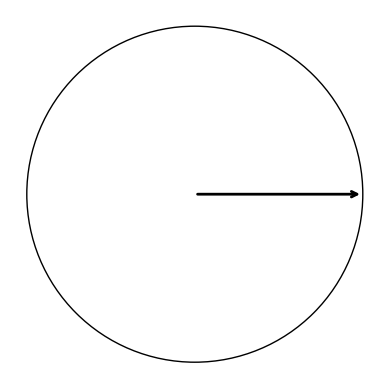

In [2]:
# Draw a diagram of a circle with an arrow coming from the centre, pointing to the boundary
# This isn't needed for working with quantum computers, but simply provides an illustration
def plot_circle_and_arrow(angle):
    """Draw a circle with an arrow pointing from the centre to the boundary, at the given angle """
    _, ax = plt.subplots()
    ax.set_aspect('equal')
    circle = plt.Circle((0,0), 1, fill=False)
    ax.add_patch(circle)
    ax.annotate('', xy=(np.cos(angle), np.sin(angle)), xytext=(0,0), arrowprops=dict(arrowstyle='->', lw=2)) 
    ax.set_xlim(-1.1,1.1)
    ax.set_ylim(-1.1,1.1)
    ax.axis('off');
plot_circle_and_arrow(0); # 0 points to the right, and np.pi/2 points up

This might seem to change everything about how probabilities work. It does not. Probability still depends only on the magnitude — the length of the arrow — not on which direction it points. Squaring the magnitude gives the probability exactly as before. The direction only matters during computation, when amplitudes from different rows combine.

The rules for directional amplitudes are simple:

| Situation | What happens |
| :- | :- |
| Probability of a row | magnitude squared — direction is ignored at measurement |
| Adding two amplitudes pointing the **same direction** | Their magnitudes add — constructive interference |
| Adding two amplitudes pointing **opposite directions** | The smaller magnitude is subtracted from the bigger magniture — destructive interference |
| Multiplying two amplitudes | Magnitudes multiply, angles add |

The QFT uses directions that are equally spaced around the circle. For a system with 8 rows (3 qubits), there are 8 equally spaced directions: 0, π/4, π/2, 3π/4, π, -3π/4, -π/2, and -π/4. We use angles measured in radians, so an angle of π is the same as 180 degrees, and 2π is 360 degrees and also equivalent to 0.

This is a simplified, but still accurate for our purposes, interpretation of the probability amplitudes. If you want to go deeper, the mathematical term for thinking about amplitudes this way is known as [polar form](https://en.wikipedia.org/wiki/Complex_number#Polar_form).

Before we begin, let's define some helper functions to help us see the directions of the amplitudes in the quantum state vector.

In [3]:
# Direction mapping to visual symbols done using degrees, for simplicity
DIRECTIONS = {0: '→', 45: '↗', 90: '↑', 135: '↖', 180: '←', 225: '↙', 270: '↓', 315: '↘'}

def direction_symbol(angle_rad):
    angle_deg = np.degrees(angle_rad) % 360    # convert to 0.0 .. 359.9
    rounded = round(angle_deg / 45) * 45 % 360 # round to the nearest 45 degrees
    return DIRECTIONS.get(rounded, '?')        # return symbol for that 45 degree direction

def angle_to_pi_str(angle_rad):
    """Convert a radian angle to a user-friendly π-fraction string (e.g. π/2, -3π/4).
    Falls back to a decimal radian value if the angle is not a clean fraction of π."""
    if abs(angle_rad) < 1e-9:
        return '0'
    ratio = angle_rad / np.pi                   # angles should generally be a fraction of pi
    frac = Fraction(ratio).limit_denominator(64)
    if abs(float(frac) - ratio) > 1e-9:         # if can't create a close fraction with up to a 64 denominator
        return f'{angle_rad:.4f}'               # just print the angle in radians
    num, den = frac.numerator, frac.denominator
    if den == 1:
        if num == 1:  return 'π'
        if num == -1: return '-π'
        return f'{num}π'
    if num == 1:  return f'π/{den}'
    if num == -1: return f'-π/{den}'
    return f'{num}π/{den}'

def show_statevector(algo):
    """Display the state vector, showing direction and magnitude for complex amplitudes. """
    n = algo.num_qubits
    v = Statevector(algo)
    data = v.data
    print(f"Qubits  {' ':>{n+2}}State vector")
    print('-' * (n + 28))
    for i, amp in enumerate(data):
        state = f"|{format(i, f'0{n}b')}>"
        if abs(amp) < 0.001:
            val = '0.0'
        elif abs(amp.imag) < 0.001:
            val = f'{amp.real:.3f}'
        else:
            mag = abs(amp)
            angle_rad = np.angle(amp)
            sym = direction_symbol(angle_rad)
            val = f'{mag:.3f}, direction {angle_to_pi_str(angle_rad)}  {sym}'
        print(f'{state:>{n+2}} (|{i}>)  {val}')

### P operation

The P operation ("phase rotation") is a new operation that makes use of directional amplitudes. It works on pairs of rows in the state vector relating to a single qubit, and rotates the direction of the amplitude in the second row anti-clockwise by a specified angle, leaving the first row unchanged.

If the amplitude in the second row was pointing right (angle 0), P(π/2) rotates it to point up (π/2). Alternatively, P(π) would rotate it to point left, which is equivalent to flipping the sign — and indeed P(π) is the same as the Z operation from the previous notebook.

Here is P in action. First, the initial state vector has both rows pointing right (the default direction) and the first row has 100% probability. Then, applying H creates a uniform probability distribution with both rows having the same magnitude. Then P(π/2) rotates the second row by π/2 to point upward.

| Qubits | Initial state vector | After H | After P(π/2) |
| :- | :- | :- | :- |
| $\rvert0\rangle$ | 1.0 | 0.707 | 0.707 |
| $\rvert1\rangle$ | 0 | 0.707 | 0.707, direction π/2  ↑ |

When P(π/2) rotates the second row, the magnitude is unchanged, so the probability stays at 50%, but the direction moves from 0 to π/2.

In [4]:
algo1 = QuantumCircuit(1) # Start with a single qubit
algo1.h(0)                # Apply the H operation
show_statevector(algo1)

Qubits     State vector
-----------------------------
|0> (|0>)  0.707
|1> (|1>)  0.707


Now see what a P(π/2) does when operating on that qubit.

In [5]:
algo1.p(np.pi / 2, 0)   # P(π/2) — rotate second row by π/2
show_statevector(algo1)

Qubits     State vector
-----------------------------
|0> (|0>)  0.707
|1> (|1>)  0.707, direction π/2  ↑


The first row is unchanged. The second row now has its amplitude pointing at π/2 — up, rather than right. The magnitude is still $\frac{1}{\sqrt{2}}$, so the probability of measuring $\rvert1\rangle$ is still 50%. The direction change has no effect on any measurement taken right now, but it will matter when this amplitude is later combined with others.

### CP operation

The CP operation ("constrained phase rotation") is to P what CX is to X. It applies P to only those pairs of rows where the specified qubit is $\rvert1\rangle$. This is the same pattern we have seen with constrained operations before, applying the operation selectively to the state vector.

CP is used extensively inside the QFT to set up the specific pattern of directions that makes directions cancel out in a helpful way.

## SWAP operation

We've already seen how X swaps rows in the state vector, but the SWAP operation is like a "column swap". To use it, you specify two qubits, and it has the same effect as if you swapped two qubit labels in the rows, and then reordered the state vector.

For example, if you had a state vector for two qubits, performing SWAP(0,1) is like relabelling row $\rvert01\rangle$ as row $\rvert10\rangle$ (and visa versa). Note that swapping the labels for rows $\rvert00\rangle$ and $\rvert11\rangle$ doesn't do anything as both qubits have the same label in those cases. Of course, SWAP(0,1) is the same as SWAP(1,0).

| Qubits | Initial state vector | After H(0) | After SWAP(0,1) |
| :- | :- | :- | :- |
| $\rvert00\rangle$ | 1.0 | 0.707 | 0.707 |
| $\rvert01\rangle$ | 0 | 0.707 | 0 |
| $\rvert10\rangle$ | 0 | 0 | 0.707 |
| $\rvert11\rangle$ | 0 | 0 | 0 |

The general case for when you have more than two qubits in the state vector is that the SWAP operation acts on pairs of rows in the state vector where one of the specified qubits is $\rvert0\rangle$ and the other is $\rvert1\rangle$ (but are otherwise the same), and swaps these. Interestingly, SWAP (column swap) and X ("row" swap) are somewhat related, as SWAP(a,b) can be achieved by performing three CX operations in sequence: CX(a,b), CX(b,a), then CX(a,b) again.

### H is already a pattern finder

Before introducing the full QFT, it is worth noticing that the H operation — first seen in [notebook 1](01_A%20simple%20and%20useful%20quantum%20algorithm.ipynb) — is already a pattern finder for the simplest possible case: two rows.

If both rows have the same sign, i.e. a uniform pattern, applying H concentrates everything into the $\rvert0\rangle$ row. If the rows have opposite signs, or one is zero and the other non-zero, i.e. an alternating pattern, H concentrates everything into the $\rvert1\rangle$ row. The lowest row (aside from 0) that has the highest amplitude tells you the frequency of the pattern. Dividing the frequency into the total number of rows tells you the period of repetition.

Let's see this directly. We will use H to create specific patterns, then apply H again and observe which row the amplitude lands in.

In [6]:
# Uniform pattern: both rows have the same value.
algo2 = QuantumCircuit(1)
algo2.h(0)  # creates uniform probability distribution
show_statevector(algo2)

Qubits     State vector
-----------------------------
|0> (|0>)  0.707
|1> (|1>)  0.707


This shows the state vector in a uniform probability distribution. Let's use the H operation, to see what it detects.

In [7]:
algo2.h(0)  # H detects the uniform pattern
show_statevector(algo2)

Qubits     State vector
-----------------------------
|0> (|0>)  1.000
|1> (|1>)  0.0


You can see that with a uniform pattern, H detects frequency '0', i.e. there's no repeating pattern. However, let's try an alternating pattern.

In [8]:
# Alternating pattern: rows have opposite signs.
algo3 = QuantumCircuit(1)
algo3.x(0)   # now 100% in second row
algo3.h(0)
show_statevector(algo3)

Qubits     State vector
-----------------------------
|0> (|0>)  0.707
|1> (|1>)  -0.707


This shows the state vector has an alternating pattern. Let's use the H operation, to see what it detects.

In [9]:
algo3.h(0)   # H detects the alternating pattern
show_statevector(algo3)

Qubits     State vector
-----------------------------
|0> (|0>)  0.0
|1> (|1>)  1.000


H has distinguished two different patterns in a 2-row state vector. Row $\rvert0\rangle$ having the greatest magnitude means "no period", i.e. uniform. Row $\rvert1\rangle$ having the greatest amplitude up means a frequency of 1, i.e. the pattern repeats once across the rows, and since there are 2 rows, the values alternate with period 2, since 2 (total rows) divided by 1 (frequency) is 2. This is pattern detection in its simplest form.

We will shortly see that the QFT generalises this to 8, 16, 32, or any power-of-2 number of rows, detecting patterns of any period using H and CP together.

### The Quantum Fourier Transform

The QFT transforms a state vector row by row. For each output row, it computes a sum of contributions — one from every input row. The direction of each contribution is determined by both the input row number and the output row number: contributions involving lower-numbered rows stay close to direction 0, while contributions involving higher-numbered rows are rotated further around the circle. When all the contributions for an output row point in the same direction, they add up to a large amplitude; when they spread evenly around the circle, they cancel to zero.

H and CP together carry out this calculation across all qubits at once. The CP operations use angles of $\frac{\pi}{2}$, $\frac{\pi}{4}$, $\frac{\pi}{8}$, and so on — quarter turns, eighth turns, sixteenth turns — to set the precise directions that make the cancellation work. A concrete example of which contributions survive and which cancel follows after the QFT is run.

The function below implements the QFT on a list of qubits.

In [10]:
def add_reverse_cols(algo, qubits, debug=False):
    """Reverse the specified columns."""
    n = len(qubits)
    for i in range(n // 2):
        if debug: print(f"SWAP({qubits[i]}, {qubits[n - 1 - i]})")
        algo.swap(qubits[i], qubits[n - 1 - i])

def add_qft(algo, qubits, debug=False):
    """Apply the Quantum Fourier Transform to the specified qubits."""
    n = len(qubits)
    for i in range(n - 1, -1, -1):
        algo.h(qubits[i])
        if debug:
            print(f"H({qubits[i]})")
            show_statevector(algo)
        for j in range(i - 1, -1, -1):
            angle = np.pi / 2 ** (i - j)
            algo.cp(angle, qubits[j], qubits[i])
            if debug:
                print(f"CP({angle}, {qubits[j]}, {qubits[i]})")
                show_statevector(algo)
    add_reverse_cols(algo, qubits, debug)

### A periodic state

To see the QFT find a period, we need a state vector with a repeating pattern. We will use 3 qubits (8 rows) and create a state where rows $\rvert0\rangle$ and $\rvert4\rangle$ have the same non-zero amplitude, and all other rows are zero. The pattern repeats twice across the state vector, i.e. *a frequency of two*.

This state vector can be constructed by applying H to just qubit 2.

| Qubits | Initial state vector | H(2) |
| :- | :- | :- |
| $\rvert000\rangle$ ($\rvert0\rangle$) | $1.0$ | $\frac{1}{\sqrt{2}}$ |
| $\rvert001\rangle$ ($\rvert1\rangle$) | $0.0$ | $0.0$ |
| $\rvert010\rangle$ ($\rvert2\rangle$) | $0.0$ | $0.0$ |
| $\rvert011\rangle$ ($\rvert3\rangle$) | $0.0$ | $0.0$ |
| $\rvert100\rangle$ ($\rvert4\rangle$) | $0.0$ | $\frac{1}{\sqrt{2}}$ |
| $\rvert101\rangle$ ($\rvert5\rangle$) | $0.0$ | $0.0$ |
| $\rvert110\rangle$ ($\rvert6\rangle$) | $0.0$ | $0.0$ |
| $\rvert111\rangle$ ($\rvert7\rangle$) | $0.0$ | $0.0$ |

In [11]:
# Prepare a frequency 2 state: non-zero at rows 0 and 4
algo4 = QuantumCircuit(3)
algo4.h(2)
show_statevector(algo4)

Qubits       State vector
-------------------------------
|000> (|0>)  0.707
|001> (|1>)  0.0
|010> (|2>)  0.0
|011> (|3>)  0.0
|100> (|4>)  0.707
|101> (|5>)  0.0
|110> (|6>)  0.0
|111> (|7>)  0.0


Now we apply the QFT to this periodic state and inspect what comes out.

In [12]:
add_qft(algo4, [0, 1, 2], debug=True)
show_statevector(algo4)

H(2)
Qubits       State vector
-------------------------------
|000> (|0>)  1.000
|001> (|1>)  0.0
|010> (|2>)  0.0
|011> (|3>)  0.0
|100> (|4>)  0.0
|101> (|5>)  0.0
|110> (|6>)  0.0
|111> (|7>)  0.0
CP(1.5707963267948966, 1, 2)
Qubits       State vector
-------------------------------
|000> (|0>)  1.000
|001> (|1>)  0.0
|010> (|2>)  0.0
|011> (|3>)  0.0
|100> (|4>)  0.0
|101> (|5>)  0.0
|110> (|6>)  0.0
|111> (|7>)  0.0
CP(0.7853981633974483, 0, 2)
Qubits       State vector
-------------------------------
|000> (|0>)  1.000
|001> (|1>)  0.0
|010> (|2>)  0.0
|011> (|3>)  0.0
|100> (|4>)  0.0
|101> (|5>)  0.0
|110> (|6>)  0.0
|111> (|7>)  0.0
H(1)
Qubits       State vector
-------------------------------
|000> (|0>)  0.707
|001> (|1>)  0.0
|010> (|2>)  0.707
|011> (|3>)  0.0
|100> (|4>)  0.0
|101> (|5>)  0.0
|110> (|6>)  0.0
|111> (|7>)  0.0
CP(1.5707963267948966, 0, 1)
Qubits       State vector
-------------------------------
|000> (|0>)  0.707
|001> (|1>)  0.0
|010> (|2>)  0.707
|011

After the QFT, rows 0, 2, 4 and 6 have the same non-zero amplitude. We ignore row 0, and the largest magnitude is 0.5, which shows up in the lowest numbered row at row 2, indicating a frequency 2 pattern. Row 0 (frequency 0) commonly appears for any periodic input — it is the contribution from the overall non-zero amplitude, not a pattern frequency.

While other higher numbered rows have the same amplitude, these can be ignored. It is like in music: frequency 2 is the fundamental tone, and the other frequencies are harmonics. The original state vector can be recovered by reversing the QFT process (also called an inverse QFT) and the information represented by the harmonics is needed for this. Spiky patterns like this one tend to create lots of harmonics. Note that there are many possible frequency 2 patterns, and each has a unique QFT result. 

This was a very simple QFT, and you can see that the applications of CP didn't do anything when processing this pattern. Firstly, H(2) immediately found a strong pattern that repeated for each value of qubit 2 (the two non-zero rows that were 4 rows apart), combining all the amplitudes into the rows where qubit 2 was $\rvert0\rangle$, which happens to be just row $\rvert000\rangle$. Next, H(1) tried to find a pattern that repeated for each value of qubit 1, and since there wasn't one, instead created a uniform distribution of amplitudes between rows $\rvert000\rangle$ and $\rvert010\rangle$. Similarly, H(0) didn't find a pattern that repeated for each value of qubit 0, uniformly distributed amplitudes across rows $\rvert000\rangle$ through $\rvert011\rangle$. Then SWAP(0,2) reordered the rows so that the final state vector represented qubit 2 corresponding to 4 row-period patterns and qubit 0 corresponding to 1 row-period patterns. It just makes the maths work.

With row 2 telling us the **frequency** of the pattern, we can determine the period from this:

$$\text{period} = \frac{N}{\text{frequency}} = \frac{8}{4} = 2$$

where N is the size of the state vector, which in this case has 8 rows.

Measurement results: {'100': 257, '110': 271, '000': 226, '010': 246}


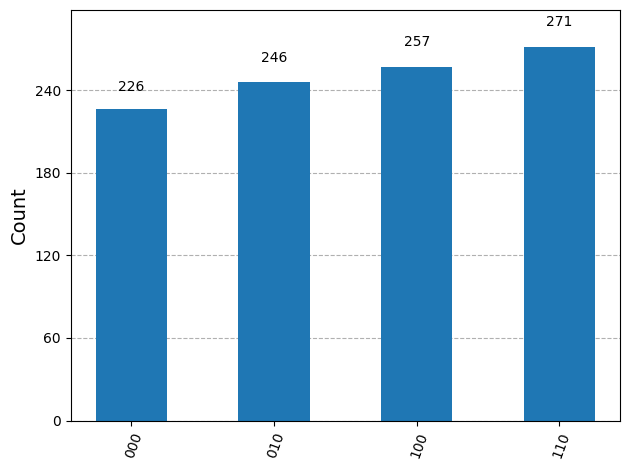

In [13]:
# Measure and run
algo5 = QuantumCircuit(3)
algo5.h(2)
add_qft(algo5, [0, 1, 2])
algo5.measure_all()

result = backend.run(transpile(algo5, backend), shots=1000).result()
counts = result.get_counts()
print('Measurement results:', counts)
plot_histogram(counts)

The histogram shows the expected similar magnitude amplitudes across four outcomes, each with roughly 25% probability. In Qiskit's output, bitstrings are written with qubit 2 on the left and qubit 0 on the right:

- **000** — this is row 0 (frequency 0, the baseline contribution)
- **010** — this is row 2 (frequency 4, indicating period 2)
- **100** — this is row 4 (a harmonic, since we've already found a similar magnitude at a previous row, so can be ignored)
- **110** — this is row 6 (a harmonic, so can be ignored)

Every other row has zero probability.

The randomness in results can complicate interpreting the QFTs output, so the **010** row may be smaller than others, although it will be similar. It should still be clear that it is the fundamental frequency, as the other higher rows are not significantly larger.

To extract the period from a measurement of row $k$:

$$\text{period} = \frac{N}{k} = \frac{8}{2} = 4$$

A classical computer could verify this in one step, but finding the period in the first place — without the QFT — would require checking each row of a large periodic function one at a time.

### QFT on a more complex case

A pattern with a period that evenly divides the number of rows is relatively simple, with the CP operations having little influence. These are always powers of 2, e.g. 2, 4, or 8. More commonly, a repeating pattern will not repeat with one of those periods, so it is worth looking at a different example before we leave the topic of QFTs.

Let's look at a period-3 pattern on a state vector with 8 rows (3 qubits). It will have rows $\rvert0\rangle$, $\rvert3\rangle$ and $\rvert6\rangle$ with the same non-zero amplitude, and with all other rows zero. While it has an integer period, it doesn't have an integer frequency: the pattern repeats two and two thirds times across the state vector. It would need 9 rows in order to repeat 3 full times.

Constructing this is a lot like the approach in [computing non-uniform probability distributions](02_Other%20random%20distributions%20on%20quantum%20computers.ipynb) where three rows of a 4 row state vector were given the same amplitude. However, we will add a couple more operations to move those amplitudes to the rows we want.

| Qubits| Initial state vector | <nobr>RY(2 $\times$ arcsin($\sqrt{1/3}$),1)</nobr> | H(0) | RY($\frac{\pi}{4}$,0) | CX(1,0) | <nobr>RY($-\frac{\pi}{4}$,0)</nobr> | CX(1,2) | CX(0,1) |
| :- | :- | :- | :- | :- | :- | :- | :- | :- |
| $\rvert000\rangle$ ($\rvert0\rangle$) | $1.0$ | $\sqrt{\frac{2}{3}}$ | $\sqrt{\frac{1}{3}}$ | $0.3125$ | $0.3125$ | $\sqrt{\frac{1}{3}}$ | $\sqrt{\frac{1}{3}}$ | $\sqrt{\frac{1}{3}}$ |
| $\rvert001\rangle$ ($\rvert1\rangle$) | $0.0$ | $0.0$                | $\sqrt{\frac{1}{3}}$ | $0.7543$ | $0.7543$ | $\sqrt{\frac{1}{3}}$ | $\sqrt{\frac{1}{3}}$ | $0.0$                |
| $\rvert010\rangle$ ($\rvert2\rangle$) | $0.0$ | $\sqrt{\frac{1}{3}}$ | $\sqrt{\frac{1}{6}}$ | $0.2209$ | $0.5334$ | $\sqrt{\frac{1}{3}}$ | $0.0$                | $0.0$                |
| $\rvert011\rangle$ ($\rvert3\rangle$) | $0.0$ | $0.0$                | $\sqrt{\frac{1}{6}}$ | $0.5334$ | $0.2209$ | $0.0$                | $0.0$                | $\sqrt{\frac{1}{3}}$ |
| $\rvert100\rangle$ ($\rvert4\rangle$) | $0.0$ | $0.0$                | $0.0$                | $0.0$    | $0.0$    | $0.0$                | $0.0$                | $0.0$                |
| $\rvert101\rangle$ ($\rvert5\rangle$) | $0.0$ | $0.0$                | $0.0$                | $0.0$    | $0.0$    | $0.0$                | $0.0$                | $0.0$                |
| $\rvert110\rangle$ ($\rvert6\rangle$) | $0.0$ | $0.0$                | $0.0$                | $0.0$    | $0.0$    | $0.0$                | $\sqrt{\frac{1}{3}}$ | $\sqrt{\frac{1}{3}}$ |
| $\rvert111\rangle$ ($\rvert7\rangle$) | $0.0$ | $0.0$                | $0.0$                | $0.0$    | $0.0$    | $0.0$                | $0.0$                | $0.0$                |


In [14]:
# Prepare a period 3 state: non-zero at rows 0, 3 and 6
angle1 = 2 * np.arcsin(np.sqrt(1.0/3.0))
angle2 = np.pi / 4
algo6 = QuantumCircuit(3)
algo6.ry(angle1, 1)       # Apply RY operation to swap 1/3 of the value of qubit 1's first rows to the second rows
algo6.h(0)                # Apply H operation on pairs of rows related to qubit 0
algo6.ry(angle2, 0)       # Apply RY operation to perform a swap equivalent to half of H on rows related to qubit 0
algo6.cx(1,0)             # Apply CX operation, constrained to rows where qubit 1 is |1>, swapping qubit 0's rows
algo6.ry(-angle2, 0)      # Apply RY operation to perform a swap equivalent to undoing half of H on qubit 0's rows
algo6.cx(1,2)             # Swap rows |2> and |6>, and |3> and |7> (which are both 0)
algo6.cx(0,1)             # Swap rows |1> and |3>, and |5> and |7> (which are both 0)
show_statevector(algo6)

Qubits       State vector
-------------------------------
|000> (|0>)  0.577
|001> (|1>)  0.0
|010> (|2>)  0.0
|011> (|3>)  0.577
|100> (|4>)  0.0
|101> (|5>)  0.0
|110> (|6>)  0.577
|111> (|7>)  0.0


Now let's see what QFT says about this state vector.

In [15]:
add_qft(algo6, [0, 1, 2], debug=True)
show_statevector(algo6)

H(2)
Qubits       State vector
-------------------------------
|000> (|0>)  0.408
|001> (|1>)  0.0
|010> (|2>)  0.408
|011> (|3>)  0.408
|100> (|4>)  0.408
|101> (|5>)  0.0
|110> (|6>)  -0.408
|111> (|7>)  0.408
CP(1.5707963267948966, 1, 2)
Qubits       State vector
-------------------------------
|000> (|0>)  0.408
|001> (|1>)  0.0
|010> (|2>)  0.408
|011> (|3>)  0.408
|100> (|4>)  0.408
|101> (|5>)  0.0
|110> (|6>)  0.408, direction -π/2  ↓
|111> (|7>)  0.408, direction π/2  ↑
CP(0.7853981633974483, 0, 2)
Qubits       State vector
-------------------------------
|000> (|0>)  0.408
|001> (|1>)  0.0
|010> (|2>)  0.408
|011> (|3>)  0.408
|100> (|4>)  0.408
|101> (|5>)  0.0
|110> (|6>)  0.408, direction -π/2  ↓
|111> (|7>)  0.408, direction 3π/4  ↖
H(1)
Qubits       State vector
-------------------------------
|000> (|0>)  0.577
|001> (|1>)  0.289
|010> (|2>)  0.0
|011> (|3>)  -0.289
|100> (|4>)  0.408, direction -π/4  ↘
|101> (|5>)  0.289, direction 3π/4  ↖
|110> (|6>)  0.408, direction

We know that this had a period-3 pattern, but dividing 8 by 3 results in a frequency of 2$\frac{2}{3}$, so there's no single row that can represent this. The largest magnitude amplitude in the lowest numbered row (other than $\rvert0\rangle$) is found in $\rvert3\rangle$, and 3 is the closest approximation to 2$\frac{2}{3}$ we can achieve. So, we have to use a bit of judgement here to interpret the QFT result and identify that it has found a period-3 pattern.

### What comes next

The QFT efficiently extracts a period from a state vector that encodes one. On its own, this is a useful tool, but the hard part of Shor's algorithm is constructing the periodic state in the first place. In Shor's algorithm, a quantum algorithm computes a modular exponentiation function across all inputs simultaneously, creating a state vector whose period is directly related to the factors of the number being factored. The QFT is then applied to reveal that period, and a short classical calculation recovers the factors.

That is the subject of the next notebook.

### In conclusion

This notebook extended the probability amplitude model to include directional amplitudes, introduced the P and CP operations that rotate those directions, and showed how the Quantum Fourier Transform uses the fact that opposite directions cancel out to reveal the period hidden in a state vector. Here is the complete set of operations across all five notebooks:

| Operation | Short-hand description | Specified by | Detailed description |
| :- | :- | :- | :- |
| H | "half" | 1 qubit | For all pairs of rows that differ only by the value of a specific qubit, replace the first row value with the *sum* of the pair divided by $\sqrt{2}$, and the second with the *difference* divided by $\sqrt{2}$. |
| CX | "constrained swap" | 2 qubits | For all pairs of rows where the first qubit is $\rvert1\rangle$ and the rows differ only in the second qubit, swap the values in the pair. |
| RY | "relative swap" | 1 angle, 1 qubit | For all pairs of rows that differ only in one qubit, partially move amplitude between them by the specified angle, introducing a sign flip on one direction. |
| X | "swap" | 1 qubit | For all pairs of rows that differ only by the value of a specific qubit, swap the values in the pair. |
| CCX | "doubly constrained swap" | 3 qubits | For all pairs of rows where both the first and second qubits are $\rvert1\rangle$ and the rows differ only in the third qubit, swap the values in the pair. |
| Z | "flip" | 1 qubit | For all pairs of rows that differ only in a specific qubit, flip the sign on the second row of each pair. |
| CCZ | "doubly constrained flip" | 3 qubits | For all pairs of rows where both the first and second qubits are $\rvert1\rangle$ and the rows differ only in the third qubit, flip the sign on the second row. |
| P | "phase rotation" | 1 angle, 1 qubit | For all pairs of rows that differ only by the value of a specified qubit, rotate the direction of the amplitude in the second row of each pair by the specified angle. |
| CP | "constrained phase rotation" | 1 angle, 2 qubits | Applies P to the target qubit only when the control qubit is $\rvert1\rangle$. |
| SWAP | "column swap" | 2 qubits | For all pairs of rows where one of the specified qubits is $\rvert0\rangle$ and the other is $\rvert1\rangle$, swap these. |